In [15]:
from hubble_utils import load_quasar_data
import pandas as pd
import numpy as np

agn_df = load_quasar_data("results/aug9_stone_N10w1000s500t6c4_merged.h5", populate_sdss=True, apply_cut=False)

stone_df = pd.read_csv('data/aug8_stone_merged.csv')

# Ensure 'object_id' is string in both dataframes before merging
agn_df['object_id'] = agn_df['object_id'].astype(str)
stone_df['object_id'] = stone_df['object_id'].astype(str)
merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))
merged_agn_stone.head()

Reading quasars from HDF5: 100%|██████████| 160/160 [00:00<00:00, 386.91it/s]

Number of quasars loaded: 160
Populating SDSS fields...
Populating SDSS fields: 160



Populating SDSS fields: 100%|██████████| 160/160 [00:08<00:00, 18.57it/s]


Writing 160 quasars to results/aug9_stone_N10w1000s500t6c4_merged.h5
Length of colin_df: 189
Number with apparent_mag_2500 > 0: 189
Length of merged DataFrame: 160
object_id not in merged: []
Number of quasars with 0 < z <= 1.0: 29
Number of quasars with z > 3: 8
Highest redshift quasar: 4.15
Columns with NaNs: ['chi_sq_g', 'chi_sq_all']
Skipping data cuts as apply_cut is False.


,DBID,RA,DEC,Z,log_M_BH,log_M_BH_ERR,log_LBOL,log_LBOL_ERR,log_TAU_OBS_g,log_TAU_OBS_g_ERR_L,...,sdss_name,sn_median_all,z,chi_sq_g,chi_sq_all,alpha_nu,alpha_nu_err,f_host_4200,apparent_mag_2500,apparent_mag_2500_err
0,2514610,43.659840,0.359089,2.4629,8.670714,0.107038,46.641548,0.019174,3.728819,0.427480,...,025438.36+002132.6,9.786992,2.464000,NaN,NaN,-0.5,0.1,-1.0,22.044209,0.1
1,2580462,43.197227,0.859788,2.1153,8.299186,0.133945,46.510011,0.031566,3.409600,0.332104,...,025247.33+005135.1,17.279648,2.114000,NaN,NaN,-0.5,0.1,-1.0,21.384800,0.1
2,2579102,40.777821,-0.425398,1.2766,8.833704,0.073575,46.003331,0.008155,3.444845,0.293526,...,024306.67-002531.4,7.616555,1.278000,688.753423,2261.497342,-0.5,0.1,-1.0,22.004661,0.1
3,2562971,40.745869,-0.177312,0.7327,7.906770,0.133784,45.285685,0.010724,2.746186,0.193387,...,024259.00-001038.3,3.498655,0.732757,56.074538,102.533414,-0.5,0.1,-1.0,21.825944,0.1
4,2478562,41.587959,-0.031133,1.2944,9.023160,0.167938,46.671580,0.001797,3.949584,0.419810,...,024621.11-000152.0,25.940512,1.294000,470.676178,1692.376251,-0.5,0.1,-1.0,20.299987,0.1


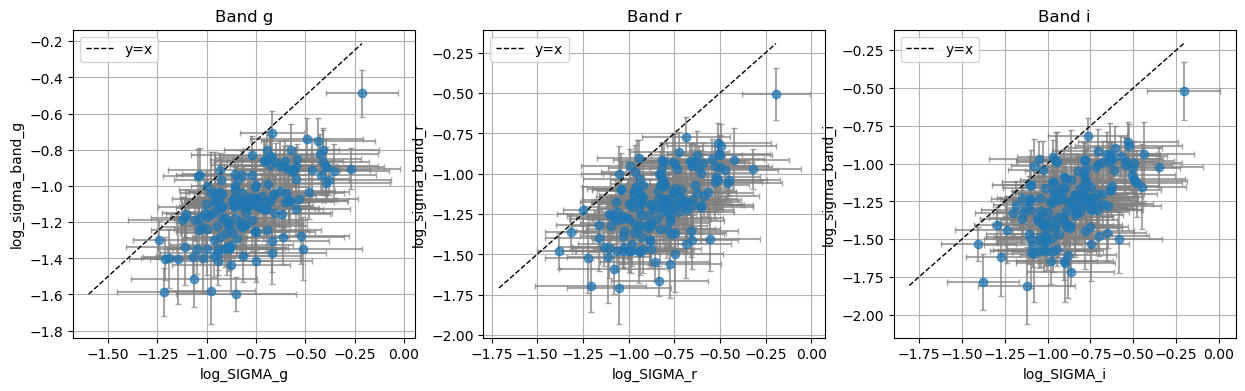

In [17]:
import matplotlib.pyplot as plt

bands = ['g', 'r', 'i']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False, sharey=False)

for ax, band in zip(axes, bands):
    x = merged_agn_stone[f'log_SIGMA_{band}']
    y = merged_agn_stone[f'log_sigma_band_{band}']
    xerr = merged_agn_stone[f'log_SIGMA_{band}_ERR_U']
    yerr = merged_agn_stone[f'log_sigma_band_{band}_err']
    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', alpha=0.7, ecolor='gray', capsize=2)
    # Add y=x line
    xy_min = min(np.nanmin(x), np.nanmin(y))
    xy_max = max(np.nanmax(x), np.nanmax(y))
    ax.plot([xy_min, xy_max], [xy_min, xy_max], 'k--', lw=1, label='y=x')
    ax.set_xlabel(f'log_SIGMA_{band}')
    ax.set_ylabel(f'log_sigma_band_{band}')
    ax.set_title(f'Band {band}')
    ax.grid(True)
    ax.legend()


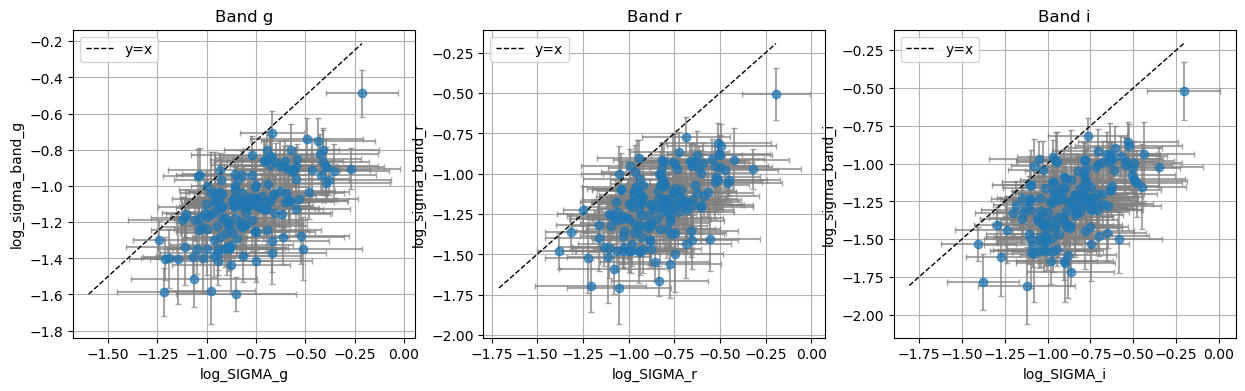

In [1]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table

bands = ['u', 'g', 'r', 'i', 'z']

def flatten_multidim_cols(tbl: Table) -> Table:
    out = Table()
    for name in tbl.colnames:
        col = tbl[name]
        if col.ndim == 1:
            out[name] = col
        else:
            # Assume shape (N, k, ...). Flatten last dims and split.
            flat = np.asarray(col).reshape(len(col), -1)
            for j in range(flat.shape[1]):
                out[f"{name}_{j}"] = flat[:, j]
    return out

t1 = Table.read("data/dr16q_prop_May01_2024.fits", hdu=1)
t1_flat = flatten_multidim_cols(t1)
fits_df = t1_flat.to_pandas()

# Load
cat = pd.read_parquet("data/S82/Catalog.parquet").reset_index()  # keep 'idx' as a column

# Clean NaNs
cat = cat[np.isfinite(cat['RA']) & np.isfinite(cat['DEC'])].copy()
t1 = t1[np.isfinite(t1['RA']) & np.isfinite(t1['DEC'])]

# Coords
c_fits = SkyCoord(t1['RA'] * u.deg, t1['DEC'] * u.deg)
c_cat  = SkyCoord(cat['RA'].to_numpy() * u.deg, cat['DEC'].to_numpy() * u.deg)

# Search within tolerance, then keep the nearest per FITS row
idx_cat, idx_fits, sep2d, _ = c_fits.search_around_sky(c_cat, seplimit=1.0 * u.arcsec)

pairs = (pd.DataFrame({
            'idx_fits': idx_fits,
            'idx_cat': idx_cat,
            'sep_arcsec': sep2d.arcsec
         })
         .sort_values(['idx_fits', 'sep_arcsec'])
         .drop_duplicates('idx_fits', keep='first')  # 1 best match per FITS row
        )

# Build matched tables
# fits_df = t1.to_pandas()
matched_fits = fits_df.iloc[pairs['idx_fits']].reset_index(drop=True)
matched_cat  = cat.iloc[pairs['idx_cat']].reset_index(drop=True)

# Optionally combine and keep separation
# Combine, keeping matched_cat columns if conflict (matched_cat takes precedence)
matched = pd.concat(
    [matched_fits, matched_cat, pairs[['sep_arcsec']].reset_index(drop=True)],
    axis=1
)
# Remove duplicate columns, keeping the last occurrence (matched_cat)
sdss = matched.loc[:, ~matched.columns.duplicated(keep='last')]

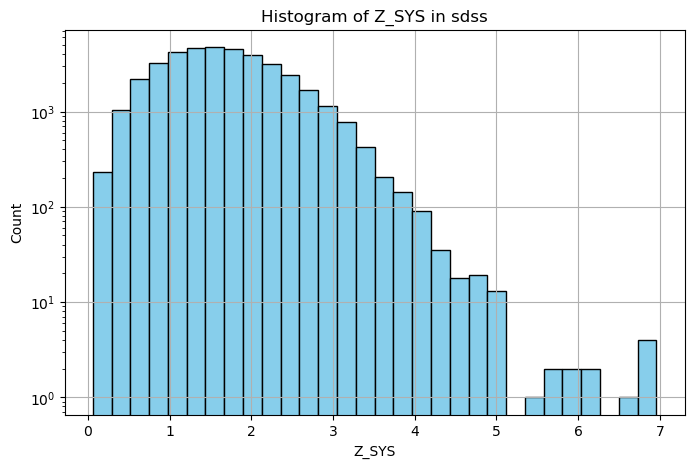

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(sdss['Z_SYS'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Z_SYS')
plt.ylabel('Count')
plt.title('Histogram of Z_SYS in sdss')
plt.grid(True)
plt.yscale('log')
plt.show()

In [7]:
print(list(sdss.keys()))

['SDSS_NAME', 'OBJID', 'SOURCE_Z_DR16Q', 'Z_FIT', 'Z_SYS_ERR', 'EBV', 'SN_MEDIAN_ALL', 'CONTI_FIT_0', 'CONTI_FIT_1', 'CONTI_FIT_2', 'CONTI_FIT_3', 'CONTI_FIT_4', 'CONTI_FIT_ERR_0', 'CONTI_FIT_ERR_1', 'CONTI_FIT_ERR_2', 'CONTI_FIT_ERR_3', 'CONTI_FIT_ERR_4', 'CONTI_STAT_0', 'CONTI_STAT_1', 'FEII_UV_0', 'FEII_UV_1', 'FEII_UV_2', 'FEII_UV_ERR_0', 'FEII_UV_ERR_1', 'FEII_UV_ERR_2', 'FEII_UV_EW', 'FEII_UV_EW_ERR', 'FEII_OPT_0', 'FEII_OPT_1', 'FEII_OPT_2', 'FEII_OPT_ERR_0', 'FEII_OPT_ERR_1', 'FEII_OPT_ERR_2', 'FEII_OPT_EW', 'FEII_OPT_EW_ERR', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL2500_ERR', 'LOGL3000', 'LOGL3000_ERR', 'LOGL5100', 'LOGL5100_ERR', 'HALPHA_0', 'HALPHA_1', 'HALPHA_2', 'HALPHA_3', 'HALPHA_4', 'HALPHA_5', 'HALPHA_BR_0', 'HALPHA_BR_1', 'HALPHA_BR_2', 'HALPHA_BR_3', 'HALPHA_BR_4', 'HALPHA_BR_5', 'NII6585_0', 'NII6585_1', 'NII6585_2', 'NII6585_3', 'NII6585_4', 'NII6585_5', 'SII6718_0', 'SII6718_1', 'SII6718_2', 'SII6718_3', 'SII6718_4', 'SII6718_5', '

In [11]:
from astropy.io import fits

hdul = fits.open('StoneLC.fits')
hdul.info()

data = hdul[1].data

# Only include fields that are 1D (flat)
flat_fields = [name for name in data.names if data[name].ndim == 1]
df_stone = pd.DataFrame({name: data[name] for name in flat_fields})

print(list(df_stone.keys()))


Filename: StoneLC.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    515   190R x 142C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 6320A, 316D, 316D, 316D, 6020A, 301D, 301D, 301D, D, 5920A, 296D, 296D, 296D, D, 49D, 49D, 49D, 49D, 49D, 49D, 49D, 49D, 49D, 49D, 49D, 49D, K, K, 1000D, 1000D, 1000D, 1000D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, K, K, 1000D, 1000D, 1000D, 1000D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, K, K, 1000D, 1000D, 1000D, 1000D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D, 3D]   
['DBID', 'RA', 'DEC', 'Z', 'log_M_BH', 'log_M_BH_ERR', 'log_LBOL', 'log_LBOL_ERR', 'log_TAU_OBS_g', 'log_TAU_OBS_g_ERR_L', 'log_TAU_OBS_g_ERR_U', 'log_TAU_REST_g', 'log_TAU_REST_g_ERR_L', 'log_TAU_REST_g_ERR_U', 'log_SIGMA

In [64]:
i = 0
data['RA'][i], data['DEC'][i]

(np.float64(41.948299), np.float64(-0.802797))

In [15]:
from hubble_utils import read_quasars_from_hdf5

agn_list = read_quasars_from_hdf5("data/aug8_bwb_stone_N20t6w4000s500/aug8_bwb_stone_N20t6w4000s500_fits_job0.h5")
df_agn = pd.DataFrame(agn_list)


Reading quasars from HDF5: 100%|██████████| 20/20 [00:00<00:00, 541.89it/s]


In [43]:
import numpy as np

def make_native_endian(df):
    df = df.copy()
    for c in df.select_dtypes(include=[np.number]).columns:
        arr = df[c].to_numpy()
        # If not native-endian, swap and update dtype
        if arr.dtype.byteorder not in ('=', '|'):
            # Swap bytes
            arr = arr.byteswap().view(arr.dtype.newbyteorder('='))
        df[c] = np.ascontiguousarray(arr)
    return df


sdss_  = make_native_endian(sdss.reset_index(drop=True))
stone_ = make_native_endian(df_stone.reset_index(drop=True))

from astropy.coordinates import SkyCoord
from astropy import units as u
import pandas as pd

c_sdss  = SkyCoord(sdss_['RA'].to_numpy(np.float64)*u.deg,
                   sdss_['DEC'].to_numpy(np.float64)*u.deg)
c_stone = SkyCoord(stone_['RA'].to_numpy(np.float64)*u.deg,
                   stone_['DEC'].to_numpy(np.float64)*u.deg)

# 1:1 nearest neighbor (sdss -> stone)
idx_stone, sep2d, _ = c_sdss.match_to_catalog_sky(c_stone)

keep = sep2d < (1.0*u.arcsec)
matched_sdss  = sdss_.loc[keep].reset_index(drop=True)
matched_stone = stone_.iloc[idx_stone[keep]].reset_index(drop=True)

stone_merged = pd.concat(
    [     matched_stone,
        matched_sdss.add_prefix('sdss_'),
     pd.DataFrame({'sep_arcsec': sep2d[keep].arcsec})],
    axis=1
)
len(stone_merged)

189

In [ ]:
stone_merged['object_id'] = stone_merged['sdss_objectId'].astype(str)
stone_merged_shuffled = stone_merged.sample(frac=1, random_state=42).reset_index(drop=True)
stone_merged_shuffled.to_csv("data/csv/aug8_stone_merged_fixed.csv", index=False)

In [71]:
df_csv = pd.read_csv("data/csv/aug8_stone_merged_fixed.csv", dtype={'object_id': str})
row = df_csv.iloc[(np.abs(df_csv['RA'] - 41.948299) + np.abs(df_csv['DEC'] - (-0.802797))).argmin()]
print(row['object_id'])
#df_csv['object_id']

1389033


In [56]:
df_csv['object_id']

0      1444387
1      1444618
2      1444568
3      1444308
4      1444631
        ...   
184    1444590
185    1444271
186    1444544
187    1444685
188    1444330
Name: object_id, Length: 189, dtype: object

In [73]:
# Merge stone_merged and df_csv by object_id (assuming the column is named 'objectId' in both)
merged_df = pd.merge(stone_merged, df_csv, left_on='object_id', right_on='object_id', how='inner')
merged_df.head()

,DBID_x,RA_x,DEC_x,Z_x,log_M_BH_x,log_M_BH_ERR_x,log_LBOL_x,log_LBOL_ERR_x,log_TAU_OBS_g_x,log_TAU_OBS_g_ERR_L_x,...,sdss_sdss_r_qg_y,sdss_sdss_i_qg_y,sdss_sdss_z_qg_y,sdss_ps1_g_qg_y,sdss_ps1_r_qg_y,sdss_ps1_i_qg_y,sdss_ps1_z_qg_y,sdss_ps1_y_qg_y,sdss_sep_arcsec_y,sep_arcsec_y
0,2591352,40.117149,-0.934969,1.0303,8.174906,0.411932,45.670646,0.009479,2.575464,0.175058,...,20.107128,20.142992,20.092385,20.345589,20.106177,20.147291,20.135960,19.987054,0.0,0.073340
1,2491485,40.156754,-0.943877,1.8330,9.011896,0.227831,46.303335,0.013239,3.494320,0.321681,...,20.036725,19.608327,19.491621,20.245825,20.017684,19.591706,19.509880,19.433140,0.0,0.064852
2,2575243,40.212906,-1.088551,1.8329,8.623792,0.725755,46.185598,0.015866,3.088469,0.236064,...,19.977125,19.728087,19.738166,19.965268,19.961533,19.715799,19.737629,19.727341,0.0,0.103299
3,2570463,40.271072,-0.859077,1.7859,9.015522,0.082269,46.135612,0.012478,3.324350,0.284845,...,20.061762,19.818998,19.814648,20.065079,20.049149,19.807754,19.815536,19.803171,0.0,0.113373
4,2554220,40.361313,-0.757293,0.7254,8.467855,0.086947,46.092621,0.002848,3.397101,0.305770,...,18.081759,18.139194,18.067906,18.121186,18.086116,18.136835,18.016924,18.218599,0.0,0.060657


Reading quasars from HDF5: 100%|██████████| 160/160 [00:00<00:00, 392.25it/s]

Number of quasars loaded: 160
Populating SDSS fields...
Populating SDSS fields: 160



Populating SDSS fields: 100%|██████████| 160/160 [00:08<00:00, 18.42it/s]


Writing 160 quasars to results/aug9_stone_N10w1000s500t6c4_merged.h5
Length of colin_df: 189
Number with apparent_mag_2500 > 0: 189
Length of merged DataFrame: 160
object_id not in merged: []
Number of quasars with 0 < z <= 1.0: 29
Number of quasars with z > 3: 8
Highest redshift quasar: 4.15
Columns with NaNs: ['chi_sq_g', 'chi_sq_all']
Skipping data cuts as apply_cut is False.


In [94]:
# Merge merged_df and agn_df on a common key, e.g., 'object_id'
# Adjust the key as needed if the column names differ


final_merged = pd.merge(merged_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))
print(list(final_merged.keys()))

['DBID_x', 'RA_x', 'DEC_x', 'Z_x', 'log_M_BH_x', 'log_M_BH_ERR_x', 'log_LBOL_x', 'log_LBOL_ERR_x', 'log_TAU_OBS_g_x', 'log_TAU_OBS_g_ERR_L_x', 'log_TAU_OBS_g_ERR_U_x', 'log_TAU_REST_g_x', 'log_TAU_REST_g_ERR_L_x', 'log_TAU_REST_g_ERR_U_x', 'log_SIGMA_g_x', 'log_SIGMA_g_ERR_L_x', 'log_SIGMA_g_ERR_U_x', 'log_JITTER_g_x', 'log_JITTER_g_ERR_L_x', 'log_JITTER_g_ERR_U_x', 'SIG0_g_x', 'SIG0_g_ERR_x', 'LAMBDA_REST_g_x', 'log_TAU_OBS_r_x', 'log_TAU_OBS_r_ERR_L_x', 'log_TAU_OBS_r_ERR_U_x', 'log_TAU_REST_r_x', 'log_TAU_REST_r_ERR_L_x', 'log_TAU_REST_r_ERR_U_x', 'log_SIGMA_r_x', 'log_SIGMA_r_ERR_L_x', 'log_SIGMA_r_ERR_U_x', 'log_JITTER_r_x', 'log_JITTER_r_ERR_L_x', 'log_JITTER_r_ERR_U_x', 'SIG0_r_x', 'SIG0_r_ERR_x', 'LAMBDA_REST_r_x', 'log_TAU_OBS_i_x', 'log_TAU_OBS_i_ERR_L_x', 'log_TAU_OBS_i_ERR_U_x', 'log_TAU_REST_i_x', 'log_TAU_REST_i_ERR_L_x', 'log_TAU_REST_i_ERR_U_x', 'log_SIGMA_i_x', 'log_SIGMA_i_ERR_L_x', 'log_SIGMA_i_ERR_U_x', 'log_JITTER_i_x', 'log_JITTER_i_ERR_L_x', 'log_JITTER_i_ERR_U_x

In [98]:
for k in final_merged.keys():
    print(k)

DBID_x
RA_x
DEC_x
Z_x
log_M_BH_x
log_M_BH_ERR_x
log_LBOL_x
log_LBOL_ERR_x
log_TAU_OBS_g_x
log_TAU_OBS_g_ERR_L_x
log_TAU_OBS_g_ERR_U_x
log_TAU_REST_g_x
log_TAU_REST_g_ERR_L_x
log_TAU_REST_g_ERR_U_x
log_SIGMA_g_x
log_SIGMA_g_ERR_L_x
log_SIGMA_g_ERR_U_x
log_JITTER_g_x
log_JITTER_g_ERR_L_x
log_JITTER_g_ERR_U_x
SIG0_g_x
SIG0_g_ERR_x
LAMBDA_REST_g_x
log_TAU_OBS_r_x
log_TAU_OBS_r_ERR_L_x
log_TAU_OBS_r_ERR_U_x
log_TAU_REST_r_x
log_TAU_REST_r_ERR_L_x
log_TAU_REST_r_ERR_U_x
log_SIGMA_r_x
log_SIGMA_r_ERR_L_x
log_SIGMA_r_ERR_U_x
log_JITTER_r_x
log_JITTER_r_ERR_L_x
log_JITTER_r_ERR_U_x
SIG0_r_x
SIG0_r_ERR_x
LAMBDA_REST_r_x
log_TAU_OBS_i_x
log_TAU_OBS_i_ERR_L_x
log_TAU_OBS_i_ERR_U_x
log_TAU_REST_i_x
log_TAU_REST_i_ERR_L_x
log_TAU_REST_i_ERR_U_x
log_SIGMA_i_x
log_SIGMA_i_ERR_L_x
log_SIGMA_i_ERR_U_x
log_JITTER_i_x
log_JITTER_i_ERR_L_x
log_JITTER_i_ERR_U_x
SIG0_i_x
SIG0_i_ERR_x
LAMBDA_REST_i_x
OFFSET_r_x
OFFSET_i_x
CARMA_P_g_x
CARMA_Q_g_x
CARMA_P_r_x
CARMA_Q_r_x
CARMA_P_i_x
CARMA_Q_i_x
sdss_SDSS_NAME_x

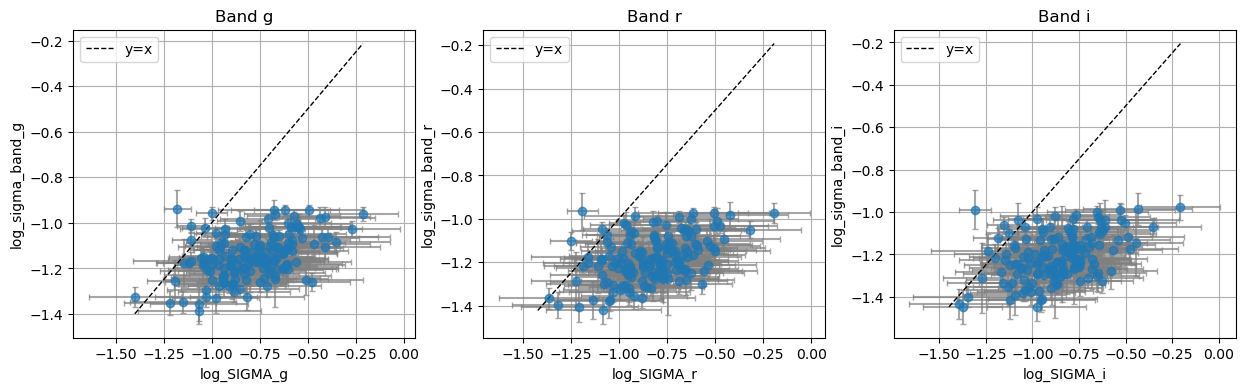

KeyError: 'log_tau_band_g'

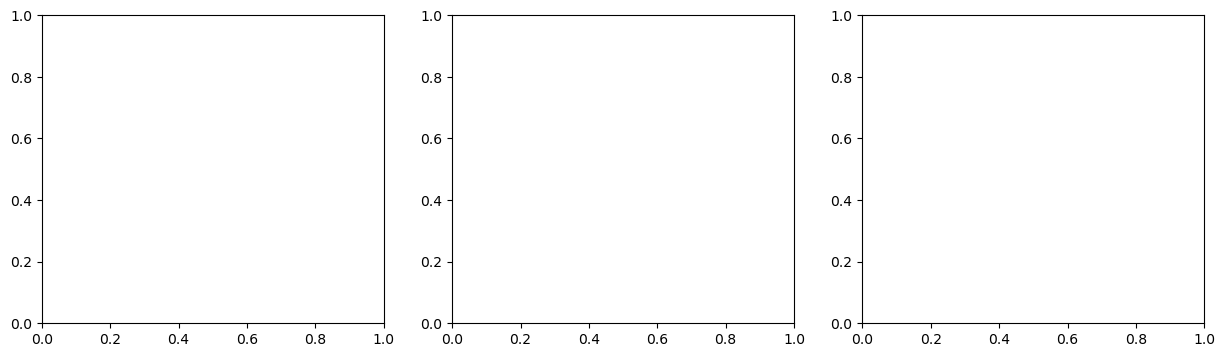

In [97]:
import matplotlib.pyplot as plt

bands = ['g', 'r', 'i']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False, sharey=False)

for ax, band in zip(axes, bands):
    x = final_merged[f'log_TAU_OBS_{band}_x']
    y = final_merged[f'log_tau_band_{band}']/np.log(10)
    xerr = final_merged[f'log_TAU_OBS_{band}_ERR_U_x']
    yerr = final_merged[f'log_tau_band_{band}_err']/np.log(10)
    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', alpha=0.7, ecolor='gray', capsize=2)
    xy_min = min(np.nanmin(x), np.nanmin(y))
    xy_max = max(np.nanmax(x), np.nanmax(y))
    ax.plot([xy_min, xy_max], [xy_min, xy_max], 'k--', lw=1, label='y=x')
    ax.set_xlabel(f'log_TAU_OBS_{band}')
    ax.set_ylabel(f'log_tau_band_{band}')
    ax.set_title(f'Band {band}')
    ax.grid(True)
    ax.legend()
